### ==========================================================================================
# NYC Jobs Pipeline – Bronze → Silver → Gold
### Optimized with Source Data Analysis, Medallion Architecture,                                                                                  Layer Tests, Feature Engineering and Visualization
### ==========================================================================================

In [1]:
# Import pyspark

import findspark
findspark.init()

In [2]:
# Import libraries

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np


In [3]:
# =====================================================
# Initialize Spark Session with Performance Optimizations
# - Enable Adaptive Query Execution for performance
# - Tune shuffle partitions
# =====================================================

In [4]:
spark = SparkSession.builder \
    .appName("NYC_Jobs_Medallion") \
    .config("spark.sql.adaptive.enabled", True) \
    .config("spark.sql.adaptive.coalescePartitions.enabled", True) \
    .config("spark.sql.shuffle.partitions", 200) \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")


# Define Medallion Layer Paths



In [23]:
csv_path = "/dataset/nyc-jobs.csv"
gold_path   = "/notebook/processed_nyc_jobs"


# Bronze Layer – Raw CSV ingestion + minimal test


In [6]:
# Read CSV
df_bronze = spark.read.option("header", True) \
                      .option("multiLine", True) \
                      .option("escape", '"') \
                      .option("inferSchema",True) \
                      .option("delimiter",",") \
                      .csv(csv_path)

# Strip whitespace and hidden characters from all column names
df_bronze = df_bronze.toDF(*[c.strip().replace("\r", "").replace("\n","").replace(" ", "_") for c in df_bronze.columns])

# Cache if reused
df_bronze.cache()

# Validate
row_count = df_bronze.count()
col_count = len(df_bronze.columns)

if row_count == 0 or col_count == 0:
    raise ValueError("Bronze layer ingestion failed.")

print("Bronze ingestion complete, rows:", row_count, "columns:", col_count)

Bronze ingestion complete, rows: 2946 columns: 28


In [7]:
# Show first 20 rows as a proper table in Jupyter
df_bronze.limit(10).toPandas()

,Job_ID,Agency,Posting_Type,#_Of_Positions,Business_Title,Civil_Service_Title,Title_Code_No,Level,Job_Category,Full-Time/Part-Time_indicator,...,Additional_Information,To_Apply,Hours/Shift,Work_Location_1,Recruitment_Contact,Residency_Requirement,Posting_Date,Post_Until,Posting_Updated,Process_Date
0,87990,DEPARTMENT OF BUSINESS SERV.,Internal,1,Account Manager,CONTRACT REVIEWER (OFFICE OF L,40563,1,None,None,...,"Salary range for this position is: $42,405 - $...",None,None,None,None,New York City residency is generally required ...,2011-06-24,None,2011-06-24,2019-12-17T00:00:00.000\r
1,97899,DEPARTMENT OF BUSINESS SERV.,Internal,1,"EXECUTIVE DIRECTOR, BUSINESS DEVELOPMENT",ADMINISTRATIVE BUSINESS PROMOT,10009,M3,None,F,...,None,"In addition to applying through this website, ...",None,None,None,New York City residency is generally required ...,2012-01-26,None,2012-01-26,2019-12-17T00:00:00.000\r
2,132292,NYC HOUSING AUTHORITY,External,52,Maintenance Worker - Technical Services-Heatin...,MAINTENANCE WORKER,90698,0,Maintenance & Operations,F,...,1. A Motor Vehicle Driverâ€™s License valid i...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirements.,2013-10-24,None,2013-12-12,2019-12-17T00:00:00.000\r
3,132292,NYC HOUSING AUTHORITY,Internal,52,Maintenance Worker - Technical Services-Heatin...,MAINTENANCE WORKER,90698,0,Maintenance & Operations,F,...,1. A Motor Vehicle Driverâ€™s License valid i...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirements.,2013-10-24,None,2013-12-12,2019-12-17T00:00:00.000\r
4,133921,NYC HOUSING AUTHORITY,Internal,50,Temporary Painter,PAINTER,91830,0,Maintenance & Operations,F,...,SPECIAL NOTE: 1. This is a temporary assig...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirement.,2014-01-09,None,2014-01-08,2019-12-17T00:00:00.000\r
5,133921,NYC HOUSING AUTHORITY,External,50,Temporary Painter,PAINTER,91830,0,Maintenance & Operations,F,...,SPECIAL NOTE: 1. This is a temporary assig...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirement.,2014-01-09,None,2014-01-08,2019-12-17T00:00:00.000\r
6,137433,DEPT OF HEALTH/MENTAL HYGIENE,Internal,1,Contract Analyst,PROCUREMENT ANALYST,12158,3,"Finance, Accounting, & Procurement",F,...,None,Apply online with a cover letter to https://a1...,None,"42-09 28th Street, Long Island City, NY",None,New York City residency is generally required ...,2013-12-09,None,2013-12-09,2019-12-17T00:00:00.000\r
7,138531,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Associate Chemist,ASSOCIATE CHEMIST,21822,2,"Health Public Safety, Inspections, & Enforcement",F,...,None,"Click the ""Apply Now"" button.",35 Hours per week/Day shift,96-05 Horace Harding Expway,None,New York City residency is generally required ...,2013-12-20,None,2014-07-25,2019-12-17T00:00:00.000\r
8,151131,NYC HOUSING AUTHORITY,External,1,Cost Estimating Manager,ADMINISTRATIVE STAFF ANALYST (,1002D,0,"Engineering, Architecture, & Planning",F,...,SPECIAL INSTRUCTIONS FOR NYCHA EMPLOYEES: N...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirements.,2014-06-25,None,2014-07-07,2019-12-17T00:00:00.000\r
9,152738,LAW DEPARTMENT,Internal,1,Office Manager,CLERICAL ASSOCIATE,10251,3,Clerical & Administrative Support,F,...,Candidates must be permanent in the Clerical A...,"Please click the ""Apply Now"" button.",Monday through Friday 9;00 am - 5:00 pm,None,None,New York City residency is generally required ...,2014-06-26,None,2014-06-26,2019-12-17T00:00:00.000\r


In [8]:
df_bronze.printSchema()

root
 |-- Job_ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting_Type: string (nullable = true)
 |-- #_Of_Positions: integer (nullable = true)
 |-- Business_Title: string (nullable = true)
 |-- Civil_Service_Title: string (nullable = true)
 |-- Title_Code_No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job_Category: string (nullable = true)
 |-- Full-Time/Part-Time_indicator: string (nullable = true)
 |-- Salary_Range_From: double (nullable = true)
 |-- Salary_Range_To: double (nullable = true)
 |-- Salary_Frequency: string (nullable = true)
 |-- Work_Location: string (nullable = true)
 |-- Division/Work_Unit: string (nullable = true)
 |-- Job_Description: string (nullable = true)
 |-- Minimum_Qual_Requirements: string (nullable = true)
 |-- Preferred_Skills: string (nullable = true)
 |-- Additional_Information: string (nullable = true)
 |-- To_Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work_Locat

---
# 1: Data Exploration

## Source Data Analysis – Column types, nulls, categorical distributions



In [9]:
def source_data_analysis(df_bronze):

    print("============== BASIC INFO ==============")
    total_rows = df_bronze.count()
    print("Total Rows :", total_rows)
    print("Total Columns :", len(df_bronze.columns))

    print("\n============== SCHEMA ==============")
    df_bronze.printSchema()

    # =====================================================
    # Duplicate Job ID Check
    # =====================================================
    print("\n============== DUPLICATE JOB ID CHECK ==============")
    df = df_bronze.groupBy("Job_ID") \
      .count() \
      .filter(col("count") > 1)
    print("Duplicate Job ID:", df.count())
    display(df.limit(5).toPandas())   

    # =====================================================
    # NULL VALUE ANALYSIS (Single Pass)
    # =====================================================
    print("\n==== Count of Missing / Null Values per Column ====")
    for c in df_bronze.columns:
        null_count = df_bronze.filter(col(c).isNull() | (col(c)=="")).count()
        print(f"{c}: {null_count}")
    
    # =====================================================
    # CATEGORICAL DISTRIBUTIONS
    # =====================================================
    print("\n============== CATEGORICAL DISTRIBUTIONS ==============")

    categorical_cols = [
        "Agency",
        "Posting_Type",
        "Job_Category",
        "Full-Time/Part-Time indicator",
        "Residency_Requirement"
    ]

    for c in categorical_cols:
        if c in df_bronze.columns:
            print(f"\nTop 5 values in: {c}")
            df_top = df_bronze.groupBy(c) \
                              .count() \
                              .orderBy(desc("count")) \
                              .limit(5)  # get top 5
        display(df_top.toPandas())
        
source_data_analysis(df_bronze)

============== BASIC INFO ==============
Total Rows : 2946
Total Columns : 28

============== SCHEMA ==============
root
 |-- Job_ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting_Type: string (nullable = true)
 |-- #_Of_Positions: integer (nullable = true)
 |-- Business_Title: string (nullable = true)
 |-- Civil_Service_Title: string (nullable = true)
 |-- Title_Code_No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job_Category: string (nullable = true)
 |-- Full-Time/Part-Time_indicator: string (nullable = true)
 |-- Salary_Range_From: double (nullable = true)
 |-- Salary_Range_To: double (nullable = true)
 |-- Salary_Frequency: string (nullable = true)
 |-- Work_Location: string (nullable = true)
 |-- Division/Work_Unit: string (nullable = true)
 |-- Job_Description: string (nullable = true)
 |-- Minimum_Qual_Requirements: string (nullable = true)
 |-- Preferred_Skills: string (nullable = true)
 |-- Additional_Information: string 

,Job_ID,count
0,396195,2
1,412113,2
2,425375,2
3,268307,2
4,289946,2



==== Count of Missing / Null Values per Column ====
Job_ID: 0
Agency: 0
Posting_Type: 0
#_Of_Positions: 0
Business_Title: 0
Civil_Service_Title: 0
Title_Code_No: 0
Level: 0
Job_Category: 2
Full-Time/Part-Time_indicator: 195
Salary_Range_From: 0
Salary_Range_To: 0
Salary_Frequency: 0
Work_Location: 0
Division/Work_Unit: 0
Job_Description: 0
Minimum_Qual_Requirements: 20
Preferred_Skills: 393
Additional_Information: 1092
To_Apply: 1
Hours/Shift: 2062
Work_Location_1: 1588
Recruitment_Contact: 2946
Residency_Requirement: 4
Posting_Date: 4
Post_Until: 2075
Posting_Updated: 4
Process_Date: 0

============== CATEGORICAL DISTRIBUTIONS ==============

Top 5 values in: Agency


,Agency,count
0,DEPT OF ENVIRONMENT PROTECTION,655
1,NYC HOUSING AUTHORITY,231
2,DEPT OF HEALTH/MENTAL HYGIENE,188
3,DEPARTMENT OF TRANSPORTATION,183
4,DEPT OF DESIGN & CONSTRUCTION,142



Top 5 values in: Posting_Type


...


Top 5 values in: Job_Category


,Job_Category,count
0,"Engineering, Architecture, & Planning",504
1,"Technology, Data & Innovation",313
2,Legal Affairs,226
3,"Public Safety, Inspections, & Enforcement",182
4,Building Operations & Maintenance,181


,Job_Category,count
0,"Engineering, Architecture, & Planning",504
1,"Technology, Data & Innovation",313
2,Legal Affairs,226
3,"Public Safety, Inspections, & Enforcement",182
4,Building Operations & Maintenance,181



Top 5 values in: Residency_Requirement


,Residency_Requirement,count
0,New York City residency is generally required ...,1705
1,New York City Residency is not required for th...,637
2,NYCHA has no residency requirements.,222
3,New York City Residency is not required for th...,216
4,This position is exempt from NYC residency req...,19



# 2: Silver Layer – Cleaning, Feature Engineering, and Tests


In [10]:
def silver_layer_enhanced(df_bronze):
    """
    Enhanced Silver layer processing with stepwise debug outputs using pandas().
    Returns the processed silver DataFrame.
    """
    
    # ===========================
    # Step 0: Clean & Deduplicate
    # ===========================
    df_bronze = df_bronze.filter(col("Posting_Date").isNotNull())
    
    window_spec = Window.partitionBy("Job_ID").orderBy(desc("Posting_Updated"))
    df_bronze = df_bronze.withColumn("rn", row_number().over(window_spec)) \
                          .filter(col("rn") == 1) \
                          .drop("rn")
    
    df_bronze = df_bronze.dropDuplicates()
    print("Step 0: Clean & Deduplicate")
    print("Row count after deduplication:", df_bronze.count())
    display(df_bronze.limit(5).toPandas())
    
    
    # ===========================
    # Step 1: Type Casting
    # ===========================
    df_bronze = df_bronze.withColumn("Job_ID", col("Job_ID").cast("int")) \
                         .withColumn("#_Of_Positions", col("#_Of_Positions").cast("int")) \
                         .withColumn("Salary_Range_From", col("Salary_Range_From").cast("double")) \
                         .withColumn("Salary_Range_To", col("Salary_Range_To").cast("double")) \
                         .withColumn("Posting_Date", to_date("Posting_Date")) \
                         .withColumn("Process_Date", to_date("Process_Date")) \
                         .withColumn("Level", col("Level").cast("int"))
    
    print("Step 1: Type Casting")
    print("Row count:", df_bronze.count())
    display(df_bronze.limit(5).toPandas())
    
    # ===========================
    # Step 2: Feature Engineering
    # ===========================
    
    # 2.1 Salary normalization & gap
    df_bronze = df_bronze.withColumn(
                            "Salary_Factor",
                         when(col("Salary_Frequency")=="Hourly", 2080)
                        .when(col("Salary_Frequency")=="Daily", 260)
                        .otherwise(1)
                                    )
    df_bronze = df_bronze.withColumn("Salary_From_Annual", col("Salary_Range_From") * col("Salary_Factor")) \
                         .withColumn("Salary_To_Annual", col("Salary_Range_To") * col("Salary_Factor")) \
                         .withColumn("Avg_Salary", (col("Salary_From_Annual") + col("Salary_To_Annual")) / 2) \
                         .withColumn("Salary_Gap", col("Salary_To_Annual") - col("Salary_From_Annual"))
    
    print("Step 2.1: Salary normalization & gap")
    print("Row count:", df_bronze.count())
    display(df_bronze.select("Salary_From_Annual", "Salary_To_Annual", "Avg_Salary", "Salary_Gap").limit(5).toPandas())
    
    # 2.2 Degree extraction & encoding
    import pyspark.sql.functions as F
    df_bronze = df_bronze.withColumn(
                            "Degree_Level",
                                F.when(F.col("Minimum_Qual_Requirements").rlike(r"ph\.?d|doctorate"), F.lit("PhD"))
                                 .when(F.col("Minimum_Qual_Requirements").rlike(r"master\'?s|m\.?b\.?a|graduate degree"), F.lit("Master"))
                                 .when(F.col("Minimum_Qual_Requirements").rlike(r"baccalaureate|bachelor|four.year college"), F.lit("Bachelor"))
                                 .when(F.col("Minimum_Qual_Requirements").rlike(r"associate|60 semester credits"), F.lit("Associate"))
                                 .when(F.col("Minimum_Qual_Requirements").rlike(r"high school|ged|equivalent"), F.lit("High school"))
                                 .otherwise(F.lit("Unspecified"))
                        ).withColumn(
                            "Degree_Encoded",
                                when(col("Degree_Level")=="PhD", 5)
                                .when(col("Degree_Level")=="Master", 4)
                                .when(col("Degree_Level")=="Bachelor", 3)
                                .when(col("Degree_Level")=="Associate", 2)
                                .when(col("Degree_Level")=="High school", 1)
                                .otherwise(0)
                                    )

    print("Step 2.2: Degree extraction & encoding")
    print("Row count:", df_bronze.count())
    display(df_bronze.select("Minimum_Qual_Requirements", "Degree_Level", "Degree_Encoded").limit(5).toPandas())
    
    # 2.3 Full-Time / Part-Time encoding
    df_bronze = df_bronze.withColumn(
                            "FT_PT_Encoded",
                                when(col("Full-Time/Part-Time_indicator")=="F", 1)
                                .when(col("Full-Time/Part-Time_indicator")=="P", 0)
                                .otherwise(-1)
                                    )
    
    print("Step 2.3: Full-Time / Part-Time encoding")
    print("Row count:", df_bronze.count())
    display(df_bronze.select("Full-Time/Part-Time_indicator", "FT_PT_Encoded").limit(5).toPandas())
    
    # 2.4 Level-to-positions ratio
    df_bronze = df_bronze.withColumn("Level_to_Positions_Ratio", col("Level") / (col("#_Of_Positions")+1))
    
    print("Step 2.4: Level-to-positions ratio")
    print("Row count:", df_bronze.count())
    display(df_bronze.select("Level", "#_Of_Positions", "Level_to_Positions_Ratio").limit(5).toPandas())
    
    # 2.5 Skill count
    # Replace None with empty string
    df_bronze = df_bronze.withColumn(
                            "Preferred_Skills",
                            when(col("Preferred_Skills").isNull(), lit("")).otherwise(col("Preferred_Skills"))
                                    )

    # Clean special/control characters from Preferred_Skills
    df_bronze = df_bronze.withColumn(
                            "Preferred_Skills",
                            trim(
                            regexp_replace(col("Preferred_Skills"), r'[\x00-\x1F\x7Fâ€¢\t\n\r]+', ' ')  # remove control chars + bullet + tabs/newlines
                                )
                                    )

    # Count number of skills per row
    df_bronze = df_bronze.withColumn(
                            "Skill_Count",
                                when(col("Preferred_Skills") == "", 0)
                                .otherwise(size(split(col("Preferred_Skills"), "[,\\.]")))  # split by comma or dot
                                    )

    print("Step 2.5: Skill count")
    print("Row count:", df_bronze.count())
    display(df_bronze.select("Preferred_Skills", "Skill_Count").limit(10).toPandas())
    
    # 2.6 Agency + JobCategory
    df_bronze = df_bronze.withColumn("Agency_JobCategory", concat_ws("_", col("Agency"), col("Job_Category")))
    
    print("Step 2.6: Agency + JobCategory")
    print("Row count:", df_bronze.count())
    display(df_bronze.select("Agency", "Job_Category", "Agency_JobCategory").limit(5).toPandas())
    
    # 2.7 Posting month & year
    df_bronze = df_bronze.withColumn("Posting_Month", month("Posting_Date")) \
                         .withColumn("Posting_Year", year("Posting_Date"))
    
    print("Step 2.7: Posting month & year")
    print("Row count:", df_bronze.count())
    display(df_bronze.select("Posting_Date", "Posting_Month", "Posting_Year").limit(5).toPandas())
    
    # ===========================
    # Step 3: Validation
    # ===========================
    errors = []
    
    if df_bronze.groupBy("Job_ID").count().filter(col("count")>1).count() > 0:
            errors.append("Duplicate Job_IDs found.")
    if df_bronze.filter(col("Avg_Salary").isNull()).count() > 0:
            errors.append("Null Avg_Salary found.")
    if df_bronze.filter(col("Salary_Gap") < 0).count() > 0:
            errors.append("Negative Salary_Gap found.")
    valid_degrees = [0, 1, 2, 3, 4, 5]
    if df_bronze.filter(~col("Degree_Encoded").isin(valid_degrees)).count() > 0:
            errors.append("Invalid Degree_Encoded values.")
    if df_bronze.filter(col("Posting_Date").isNull()).count() > 0:
            errors.append("Null Posting_Date found.")
    
    if errors:
        raise ValueError("Silver layer validation failed:\n" + "\n".join(errors))
    else:
        print("Silver layer validation successfully completed.")
    
    print("Final Silver Layer Row count:", df_bronze.count())
    display(df_bronze.limit(5).toPandas())
    
    return df_bronze

# ===========================
# Run the silver layer
# ===========================
df_silver = silver_layer_enhanced(df_bronze)

Step 0: Clean & Deduplicate
Row count after deduplication: 1659


,Job_ID,Agency,Posting_Type,#_Of_Positions,Business_Title,Civil_Service_Title,Title_Code_No,Level,Job_Category,Full-Time/Part-Time_indicator,...,Additional_Information,To_Apply,Hours/Shift,Work_Location_1,Recruitment_Contact,Residency_Requirement,Posting_Date,Post_Until,Posting_Updated,Process_Date
0,87990,DEPARTMENT OF BUSINESS SERV.,Internal,1,Account Manager,CONTRACT REVIEWER (OFFICE OF L,40563,1,None,None,...,"Salary range for this position is: $42,405 - $...",None,None,None,None,New York City residency is generally required ...,2011-06-24,None,2011-06-24,2019-12-17T00:00:00.000\r
1,97899,DEPARTMENT OF BUSINESS SERV.,Internal,1,"EXECUTIVE DIRECTOR, BUSINESS DEVELOPMENT",ADMINISTRATIVE BUSINESS PROMOT,10009,M3,None,F,...,None,"In addition to applying through this website, ...",None,None,None,New York City residency is generally required ...,2012-01-26,None,2012-01-26,2019-12-17T00:00:00.000\r
2,132292,NYC HOUSING AUTHORITY,External,52,Maintenance Worker - Technical Services-Heatin...,MAINTENANCE WORKER,90698,0,Maintenance & Operations,F,...,1. A Motor Vehicle Driverâ€™s License valid i...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirements.,2013-10-24,None,2013-12-12,2019-12-17T00:00:00.000\r
3,133921,NYC HOUSING AUTHORITY,Internal,50,Temporary Painter,PAINTER,91830,0,Maintenance & Operations,F,...,SPECIAL NOTE: 1. This is a temporary assig...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirement.,2014-01-09,None,2014-01-08,2019-12-17T00:00:00.000\r
4,137433,DEPT OF HEALTH/MENTAL HYGIENE,Internal,1,Contract Analyst,PROCUREMENT ANALYST,12158,3,"Finance, Accounting, & Procurement",F,...,None,Apply online with a cover letter to https://a1...,None,"42-09 28th Street, Long Island City, NY",None,New York City residency is generally required ...,2013-12-09,None,2013-12-09,2019-12-17T00:00:00.000\r


Step 1: Type Casting
Row count: 1659


,Job_ID,Agency,Posting_Type,#_Of_Positions,Business_Title,Civil_Service_Title,Title_Code_No,Level,Job_Category,Full-Time/Part-Time_indicator,...,Additional_Information,To_Apply,Hours/Shift,Work_Location_1,Recruitment_Contact,Residency_Requirement,Posting_Date,Post_Until,Posting_Updated,Process_Date
0,87990,DEPARTMENT OF BUSINESS SERV.,Internal,1,Account Manager,CONTRACT REVIEWER (OFFICE OF L,40563,1.0,None,None,...,"Salary range for this position is: $42,405 - $...",None,None,None,None,New York City residency is generally required ...,2011-06-24,None,2011-06-24,2019-12-17
1,97899,DEPARTMENT OF BUSINESS SERV.,Internal,1,"EXECUTIVE DIRECTOR, BUSINESS DEVELOPMENT",ADMINISTRATIVE BUSINESS PROMOT,10009,NaN,None,F,...,None,"In addition to applying through this website, ...",None,None,None,New York City residency is generally required ...,2012-01-26,None,2012-01-26,2019-12-17
2,132292,NYC HOUSING AUTHORITY,External,52,Maintenance Worker - Technical Services-Heatin...,MAINTENANCE WORKER,90698,0.0,Maintenance & Operations,F,...,1. A Motor Vehicle Driverâ€™s License valid i...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirements.,2013-10-24,None,2013-12-12,2019-12-17
3,133921,NYC HOUSING AUTHORITY,Internal,50,Temporary Painter,PAINTER,91830,0.0,Maintenance & Operations,F,...,SPECIAL NOTE: 1. This is a temporary assig...,"Click the ""Apply Now"" button.",None,None,None,NYCHA has no residency requirement.,2014-01-09,None,2014-01-08,2019-12-17
4,137433,DEPT OF HEALTH/MENTAL HYGIENE,Internal,1,Contract Analyst,PROCUREMENT ANALYST,12158,3.0,"Finance, Accounting, & Procurement",F,...,None,Apply online with a cover letter to https://a1...,None,"42-09 28th Street, Long Island City, NY",None,New York City residency is generally required ...,2013-12-09,None,2013-12-09,2019-12-17


Step 2.1: Salary normalization & gap
Row count: 1659


...

,Agency,Job_Category,Agency_JobCategory
0,DEPARTMENT OF BUSINESS SERV.,None,DEPARTMENT OF BUSINESS SERV.
1,DEPARTMENT OF BUSINESS SERV.,None,DEPARTMENT OF BUSINESS SERV.
2,NYC HOUSING AUTHORITY,Maintenance & Operations,NYC HOUSING AUTHORITY_Maintenance & Operations
3,NYC HOUSING AUTHORITY,Maintenance & Operations,NYC HOUSING AUTHORITY_Maintenance & Operations
4,DEPT OF HEALTH/MENTAL HYGIENE,"Finance, Accounting, & Procurement","DEPT OF HEALTH/MENTAL HYGIENE_Finance, Account..."


Step 2.7: Posting month & year
Row count: 1659


,Posting_Date,Posting_Month,Posting_Year
0,2011-06-24,6,2011
1,2012-01-26,1,2012
2,2013-10-24,10,2013
3,2014-01-09,1,2014
4,2013-12-09,12,2013


Silver layer validation successfully completed.
Final Silver Layer Row count: 1659


,Job_ID,Agency,Posting_Type,#_Of_Positions,Business_Title,Civil_Service_Title,Title_Code_No,Level,Job_Category,Full-Time/Part-Time_indicator,...,Avg_Salary,Salary_Gap,Degree_Level,Degree_Encoded,FT_PT_Encoded,Level_to_Positions_Ratio,Skill_Count,Agency_JobCategory,Posting_Month,Posting_Year
0,87990,DEPARTMENT OF BUSINESS SERV.,Internal,1,Account Manager,CONTRACT REVIEWER (OFFICE OF L,40563,1.0,None,None,...,53945.0,23080.00,Bachelor,3,-1,0.5,6,DEPARTMENT OF BUSINESS SERV.,6,2011
1,97899,DEPARTMENT OF BUSINESS SERV.,Internal,1,"EXECUTIVE DIRECTOR, BUSINESS DEVELOPMENT",ADMINISTRATIVE BUSINESS PROMOT,10009,NaN,None,F,...,111377.0,101274.00,Bachelor,3,1,NaN,0,DEPARTMENT OF BUSINESS SERV.,1,2012
2,132292,NYC HOUSING AUTHORITY,External,52,Maintenance Worker - Technical Services-Heatin...,MAINTENANCE WORKER,90698,0.0,Maintenance & Operations,F,...,53244.0,2672.64,High school,1,1,0.0,16,NYC HOUSING AUTHORITY_Maintenance & Operations,10,2013
3,133921,NYC HOUSING AUTHORITY,Internal,50,Temporary Painter,PAINTER,91830,0.0,Maintenance & Operations,F,...,72800.0,0.00,Unspecified,0,1,0.0,0,NYC HOUSING AUTHORITY_Maintenance & Operations,1,2014
4,137433,DEPT OF HEALTH/MENTAL HYGIENE,Internal,1,Contract Analyst,PROCUREMENT ANALYST,12158,3.0,"Finance, Accounting, & Procurement",F,...,67825.5,34455.00,Bachelor,3,1,1.5,4,"DEPT OF HEALTH/MENTAL HYGIENE_Finance, Account...",12,2013


In [11]:
df_silver.printSchema()

root
 |-- Job_ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting_Type: string (nullable = true)
 |-- #_Of_Positions: integer (nullable = true)
 |-- Business_Title: string (nullable = true)
 |-- Civil_Service_Title: string (nullable = true)
 |-- Title_Code_No: string (nullable = true)
 |-- Level: integer (nullable = true)
 |-- Job_Category: string (nullable = true)
 |-- Full-Time/Part-Time_indicator: string (nullable = true)
 |-- Salary_Range_From: double (nullable = true)
 |-- Salary_Range_To: double (nullable = true)
 |-- Salary_Frequency: string (nullable = true)
 |-- Work_Location: string (nullable = true)
 |-- Division/Work_Unit: string (nullable = true)
 |-- Job_Description: string (nullable = true)
 |-- Minimum_Qual_Requirements: string (nullable = true)
 |-- Preferred_Skills: string (nullable = true)
 |-- Additional_Information: string (nullable = true)
 |-- To_Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work_Loca


# 3: Gold Layer – KPI Computation, Validation, and Storage


In [24]:
def gold_layer(df_silver, gold_path):

    import os
    os.makedirs(gold_path, exist_ok=True)

    # Helper to write KPI as parquet via Pandas
    def write_kpi(df, path, name):
        os.makedirs(path, exist_ok=True)
        pdf = df.toPandas()
        row_count = len(pdf)
        print(f"Writing {name}: {row_count} rows")
        if row_count == 0:
            raise ValueError(f" {name} is empty — aborting write.")
        pdf.to_parquet(f"{path}/part-00000.parquet", index=False, engine="pyarrow")
        print(f" {name} written — {row_count} rows")
        return df

    # KPI1: Top 10 Job Categories
    kpi1 = df_silver.groupBy("Job_Category").count().orderBy(col("count").desc()).limit(10)
    print("KPI1: Top 10 Job Categories"); display(kpi1.toPandas())

    # KPI2: Salary Distribution per Category
    kpi2 = df_silver.groupBy("Job_Category").agg(
        avg("Avg_Salary").alias("Avg_Salary"),
        min("Avg_Salary").alias("Min_Salary"),
        max("Avg_Salary").alias("Max_Salary"),
        count("Avg_Salary").alias("Count")
    ).orderBy(col("Avg_Salary").desc())
    print("KPI2: Salary Distribution"); display(kpi2.limit(5).toPandas())

    # KPI3: Highest Salary per Agency
    windowSpec = Window.partitionBy("Agency").orderBy(col("Salary_To_Annual").desc())
    kpi3 = df_silver.withColumn("rank", row_number().over(windowSpec)) \
                    .filter(col("rank") == 1) \
                    .select("Agency", "Business_Title", "Salary_To_Annual") \
                    .orderBy(col("Salary_To_Annual").desc())
    print("KPI3: Highest Salary per Agency"); display(kpi3.limit(5).toPandas())

    # KPI4: Average Salary Last 2 Years
    max_date = df_silver.select(max("Posting_Date")).collect()[0][0]
    cutoff_date = pd.to_datetime(max_date) - pd.Timedelta(days=730)
    kpi4 = df_silver.filter(col("Posting_Date") >= cutoff_date) \
                    .groupBy("Agency") \
                    .agg(avg("Avg_Salary").alias("Avg_Salary_Last_2_Years")) \
                    .orderBy(col("Avg_Salary_Last_2_Years").desc())
    print("KPI4: Avg Salary Last 2 Years"); display(kpi4.limit(5).toPandas())

    # KPI5: Highest Paid Skills
    df_skills = df_silver.withColumn(
        "Skill", explode(split(regexp_replace(col("Preferred_Skills"), "â€¢", ""), "[,\\n\\.]"))
    ).withColumn("Skill", trim(col("Skill"))) \
     .filter((length(col("Skill")) >= 4) & (length(col("Skill")) <= 80))
    skill_freq = df_skills.groupBy("Skill").count().filter(col("count") >= 5)
    kpi5 = df_skills.join(skill_freq, "Skill") \
                    .groupBy("Skill") \
                    .agg(avg("Avg_Salary").alias("Avg_Salary")) \
                    .orderBy(col("Avg_Salary").desc())
    print("KPI5: Highest Paid Skills"); display(kpi5.limit(5).toPandas())

    # KPI6: Degree vs Avg Salary
    kpi6 = df_silver.groupBy("Degree_Level") \
                    .agg(avg("Avg_Salary").alias("Avg_Salary")) \
                    .orderBy(col("Avg_Salary").desc())
    print("KPI6: Degree vs Avg Salary"); display(kpi6.toPandas())

    # Validation
    errors = []
    if kpi1.count() < 10:
        errors.append("KPI1: Less than 10 job categories.")
    if kpi4.count() == 0:
        errors.append("KPI4: Empty.")
    if kpi5.filter(col("Avg_Salary").isNotNull()).count() == 0:
        errors.append("KPI5: No valid skills.")
    if kpi6.count() == 0:
        errors.append("KPI6: Empty.")
    if errors:
        raise ValueError("Gold validation failed:\n" + "\n".join(errors))
    print(" Gold layer validation passed.")

    # Write all KPIs
    write_kpi(kpi1, f"{gold_path}/top10_jobs",               "KPI1 - Top 10 Jobs")
    write_kpi(kpi2, f"{gold_path}/salary_dist",               "KPI2 - Salary Dist")
    write_kpi(kpi3, f"{gold_path}/highest_salary_per_agency", "KPI3 - Highest Salary")
    write_kpi(kpi4, f"{gold_path}/avg_salary_last_2_years",   "KPI4 - Avg Salary 2yr")
    write_kpi(kpi5, f"{gold_path}/highest_paid_skills",       "KPI5 - Top Skills")
    write_kpi(kpi6, f"{gold_path}/degree_salary_corr",        "KPI6 - Degree Salary")

    return kpi1, kpi2, kpi3, kpi4, kpi5, kpi6

# Run
kpi1, kpi2, kpi3, kpi4, kpi5, kpi6 = gold_layer(df_silver, gold_path)

KPI1: Top 10 Job Categories


,Job_Category,count
0,"Engineering, Architecture, & Planning",260
1,"Technology, Data & Innovation",182
2,Legal Affairs,120
3,Building Operations & Maintenance,99
4,"Finance, Accounting, & Procurement",98
5,"Public Safety, Inspections, & Enforcement",98
6,Administration & Human Resources,88
7,Health,69
8,Constituent Services & Community Programs,68
9,"Policy, Research & Analysis",64


KPI2: Salary Distribution


,Job_Category,Avg_Salary,Min_Salary,Max_Salary,Count
0,"Administration & Human Resources Finance, Acco...",218587.0,218587.0,218587.0,1
1,"Engineering, Architecture, & Planning Maintena...",198518.0,198518.0,198518.0,1
2,"Engineering, Architecture, & Planning Finance,...",196042.5,182500.0,209585.0,2
3,"Health Policy, Research & Analysis Public Safe...",128694.5,94889.0,162500.0,2
4,"Engineering, Architecture, & Planning Policy, ...",128247.5,128247.5,128247.5,2


KPI3: Highest Salary per Agency


...

KPI5: Highest Paid Skills


,Skill,Avg_Salary
0,and supervisory techniques and principles,137253.200000
1,personnel management,137253.200000
2,public utility,133171.285714
3,MySQL,116821.416667
4,Exceptional leadership abilities,116680.900000


KPI6: Degree vs Avg Salary


,Degree_Level,Avg_Salary
0,Master,91458.940537
1,PhD,84036.897727
2,Unspecified,78261.650326
3,Bachelor,76732.131032
4,High school,62049.242960
5,Associate,55438.369231


 Gold layer validation passed.
Writing KPI1 - Top 10 Jobs: 10 rows
 KPI1 - Top 10 Jobs written — 10 rows
Writing KPI2 - Salary Dist: 131 rows
 KPI2 - Salary Dist written — 131 rows
Writing KPI3 - Highest Salary: 52 rows
 KPI3 - Highest Salary written — 52 rows
Writing KPI4 - Avg Salary 2yr: 51 rows
 KPI4 - Avg Salary 2yr written — 51 rows
Writing KPI5 - Top Skills: 278 rows
 KPI5 - Top Skills written — 278 rows
Writing KPI6 - Degree Salary: 6 rows
 KPI6 - Degree Salary written — 6 rows


In [28]:
# Parquet is a binary format, not UTF-8 text.
# Do NOT open these files directly in Jupyter's file browser —
# it will show "not UTF-8 encoded" error which is expected and harmless.
# Use pd.read_parquet() or spark.read.parquet() to read them correctly.

import pandas as pd

for name in ["top10_jobs", "salary_dist", "highest_salary_per_agency",
             "avg_salary_last_2_years", "highest_paid_skills", "degree_salary_corr"]:
    df_check = pd.read_parquet(f"{gold_path}/{name}/part-00000.parquet")
    print(f" {name}: {len(df_check)} rows")
    display(df_check.head(3))
    print("─" * 50)

 top10_jobs: 10 rows


,Job_Category,count
0,"Engineering, Architecture, & Planning",260
1,"Technology, Data & Innovation",182
2,Legal Affairs,120


──────────────────────────────────────────────────
 salary_dist: 131 rows


,Job_Category,Avg_Salary,Min_Salary,Max_Salary,Count
0,"Administration & Human Resources Finance, Acco...",218587.0,218587.0,218587.0,1
1,"Engineering, Architecture, & Planning Maintena...",198518.0,198518.0,198518.0,1
2,"Engineering, Architecture, & Planning Finance,...",196042.5,182500.0,209585.0,2


──────────────────────────────────────────────────
 highest_salary_per_agency: 52 rows


...

──────────────────────────────────────────────────
 highest_paid_skills: 278 rows


,Skill,Avg_Salary
0,and supervisory techniques and principles,137253.200000
1,personnel management,137253.200000
2,public utility,133171.285714


──────────────────────────────────────────────────
 degree_salary_corr: 6 rows


,Degree_Level,Avg_Salary
0,Master,91458.940537
1,PhD,84036.897727
2,Unspecified,78261.650326


──────────────────────────────────────────────────



# 4. Visualizations (Pandas + Matplotlib/Seaborn)


## 1. KPI1 – Top 10 Job Categories

Row count: 10


,Job_Category,count
0,"Engineering, Architecture, & Planning",260
1,"Technology, Data & Innovation",182
2,Legal Affairs,120
3,Building Operations & Maintenance,99
4,"Finance, Accounting, & Procurement",98


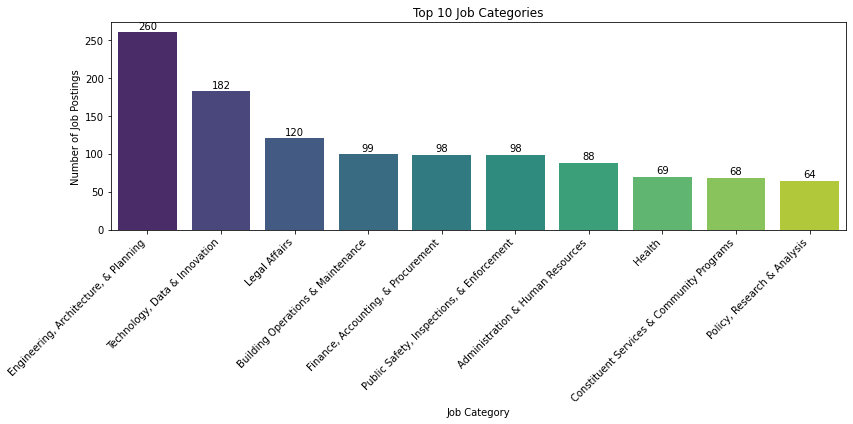

In [14]:
# 1. KPI1 – Top 10 Job Categories
print("Row count:", kpi1.count())
display(kpi1.limit(5).toPandas())
kpi1_pd = kpi1.toPandas()

plt.figure(figsize=(12,6))
ax = sns.barplot(data=kpi1_pd, x="Job_Category", y="count", palette="viridis")

plt.title("Top 10 Job Categories")
plt.ylabel("Number of Job Postings")
plt.xlabel("Job Category")
plt.xticks(rotation=45, ha='right')

# Add count labels on top of each bar
for i, value in enumerate(kpi1_pd["count"]):
    ax.text(i, value + 2, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 2.KPI2 – Top 10 Salary Distribution per Job Category (Average Salary Only)

Top 10 Job Categories by Avg Salary : 10 rows


,Job_Category,Avg_Salary,Min_Salary,Max_Salary,Count
0,"Administration & Human Resources Finance, Acco...",218587.000000,218587.00,218587.00,1
1,"Engineering, Architecture, & Planning Maintena...",198518.000000,198518.00,198518.00,1
2,"Engineering, Architecture, & Planning Finance,...",196042.500000,182500.00,209585.00,2
3,"Health Policy, Research & Analysis Public Safe...",128694.500000,94889.00,162500.00,2
4,"Engineering, Architecture, & Planning Policy, ...",128247.500000,128247.50,128247.50,2
5,"Engineering, Architecture, & Planning Technolo...",128247.500000,128247.50,128247.50,1
6,Communications & Intergovernmental Affairs Eng...,125000.000000,125000.00,125000.00,1
7,Constituent Services & Community Programs Fina...,122182.320000,122182.32,122182.32,1
8,"Administration & Human Resources Finance, Acco...",118287.000000,118287.00,118287.00,1
9,Constituent Services & Community Programs Comm...,116900.333333,58500.00,217201.00,3


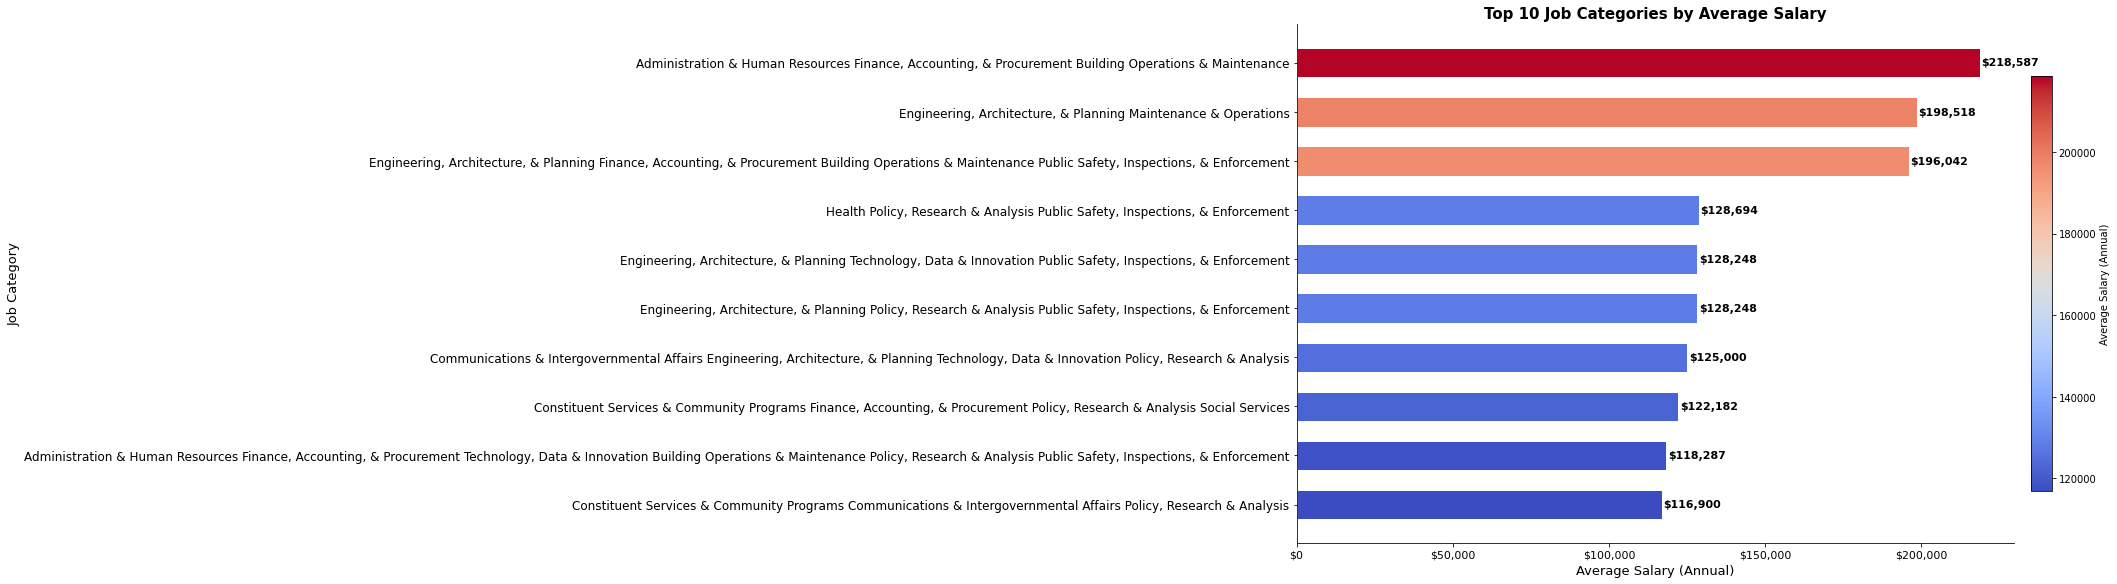

In [15]:
# 2.KPI2 – Top 10 Salary Distribution per Job Category (Average Salary Only)
# Horizontal bar chart with color gradient — clean and easy to compare avg salary per category.

kpi2_pd = kpi2.toPandas()

# Top 10 by Avg_Salary sorted descending for table display
top10_jobs = kpi2_pd.sort_values("Avg_Salary", ascending=False).head(10)
print(f"Top 10 Job Categories by Avg Salary : {len(top10_jobs)} rows")
display(top10_jobs)

# Sort ascending for chart (highest appears at top)
top10_chart = top10_jobs.sort_values("Avg_Salary", ascending=True)

# Color gradient based on Avg_Salary
norm   = plt.Normalize(top10_chart["Avg_Salary"].min(), top10_chart["Avg_Salary"].max())
colors = cm.coolwarm(norm(top10_chart["Avg_Salary"]))

# Increased figure size to accommodate colorbar and larger labels
fig, ax = plt.subplots(figsize=(20, 9))

# Horizontal bar chart
bars = ax.barh(top10_chart["Job_Category"], top10_chart["Avg_Salary"],
               color=colors, edgecolor='white', height=0.6)

# Add salary labels at end of each bar
for bar, value in zip(bars, top10_chart["Avg_Salary"]):
    ax.text(value + 500, bar.get_y() + bar.get_height() / 2,
            f"${value:,.0f}", va='center', fontsize=11, fontweight='bold')

# Colorbar legend
sm = cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Average Salary (Annual)', pad=0.02, shrink=0.8)

ax.set_title("Top 10 Job Categories by Average Salary", fontweight='bold', fontsize=15)
ax.set_xlabel("Average Salary (Annual)", fontsize=13)
ax.set_ylabel("Job Category",            fontsize=13)

# ✅ Increase y-axis (Job Category names) font size
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=11)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Fix margins to avoid tight layout warning
plt.subplots_adjust(left=0.28, right=0.88, top=0.92, bottom=0.12)
plt.show()

## 3.KPI3 – Highest Salary per Agency

Top 10 Highest Salary Agencies : 10 rows


,Agency,Business_Title,Salary_To_Annual
0,NYC EMPLOYEES RETIREMENT SYS,COMPUTER SYSTEMS MANAGER,234402.000
2,POLICE DEPARTMENT,"Deputy Commissioner, Public Information, M-VII",234402.000
1,NYC HOUSING AUTHORITY,executive Vice President for Operations,234402.000
3,DEPT OF HEALTH/MENTAL HYGIENE,"Deputy Commissioner, Family & Child Health",225217.000
4,DEPT OF ENVIRONMENT PROTECTION,"Deputy Commissioner, Bureau of Customer Services",218587.000
5,DEPT OF DESIGN & CONSTRUCTION,Associate Commissioner,217244.000
6,DISTRICT ATTORNEY KINGS COUNTY,Co-Chief Information Officer,208826.000
7,DEPARTMENT OF SANITATION,"ASSISTANT COMMISSIONER, PUBLIC AFFAIRS",202744.000
8,DEPT OF INFO TECH & TELECOMM,"Associate Commissioner, IT Operations",189000.000
9,DEPARTMENT OF CORRECTION,Infrastructure Project Manager,184610.192


Top 10 Lowest Salary Agencies  : 10 rows


,Agency,Business_Title,Salary_To_Annual
42,NYC DEPT OF VETERANS' SERVICES,Director of Housing Initiatives,92001.0
43,TAX COMMISSION,CITY ASSESSOR,90177.0
44,OFFICE OF EMERGENCY MANAGEMENT,DISABILITY ACCESS AND FUNCTIONAL NEEDS MANAGER,85000.0
45,DEPARTMENT OF BUILDINGS,Borough Enforcement Attorney,82137.0
46,TEACHERS RETIREMENT SYSTEM,AGENCY ATTORNEY INTERNE,75760.0
47,EQUAL EMPLOY PRACTICES COMM,Director of Learning and Development,72712.0
48,LANDMARKS PRESERVATION COMM,"LANDMARKS PRESERVATIONIST, PRESERVATION DEPT",64297.0
49,PUBLIC ADMINISTRATOR-NEW YORK,BOOKKEEPER,49349.0
50,MANHATTAN COMMUNITY BOARD #8,Community Assistant,39520.0
51,OFFICE OF COLLECTIVE BARGAININ,COLLEGE AIDE - CLERICAL,21548.8


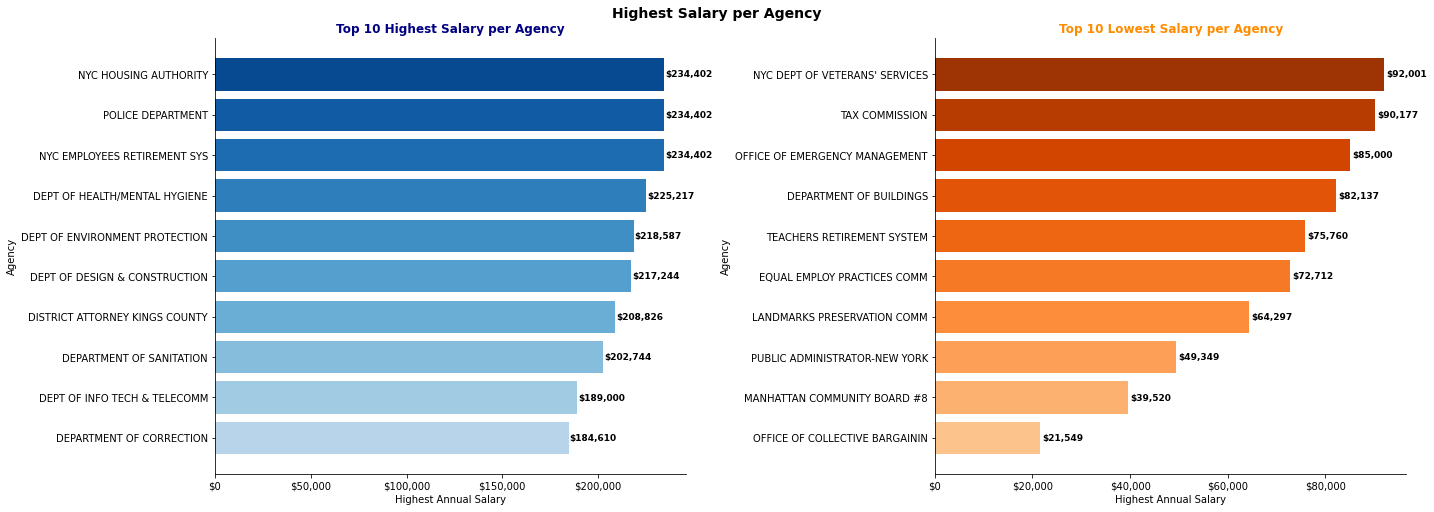

In [16]:
# 3.KPI3 – Highest Salary per Agency

# Side-by-side horizontal bar chart showing Top 10 Highest and Top 10 Lowest

kpi3_pd = kpi3.toPandas().sort_values(by="Salary_To_Annual", ascending=False)

# Split into Top 10 Highest and Top 10 Lowest
top10    = kpi3_pd.head(10)
bottom10 = kpi3_pd.tail(10).sort_values(by="Salary_To_Annual", ascending=False)

# Print row counts and display tables in descending order
print(f"Top 10 Highest Salary Agencies : {len(top10)} rows")
display(top10)

print(f"Top 10 Lowest Salary Agencies  : {len(bottom10)} rows")
display(bottom10)

# Sort ascending for chart (highest appears at top of horizontal bar)
top10_chart    = top10.sort_values(by="Salary_To_Annual", ascending=True)
bottom10_chart = bottom10.sort_values(by="Salary_To_Annual", ascending=True)

# Dark → Light: highest salary gets dark color, lowest gets light color
# Top 10: Dark Blue (0.9) → Light Blue (0.3) bottom to top
# Bottom 10: Dark Orange (0.9) → Light Orange (0.3) bottom to top
top_colors    = cm.Blues(np.linspace(0.3, 0.9, len(top10_chart)))      # light → dark (ascending chart)
bottom_colors = cm.Oranges(np.linspace(0.3, 0.9, len(bottom10_chart))) # light → dark (ascending chart)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ── Left: Top 10 Highest (Blue — Dark = Highest) ──
bars_top = axes[0].barh(top10_chart["Agency"], top10_chart["Salary_To_Annual"],
                         color=top_colors)
for bar, value in zip(bars_top, top10_chart["Salary_To_Annual"]):
    axes[0].text(value + 500, bar.get_y() + bar.get_height() / 2,
                 f"${value:,.0f}", va='center', fontsize=9, fontweight='bold')
axes[0].set_title("Top 10 Highest Salary per Agency", fontweight='bold', color='navy')
axes[0].set_xlabel("Highest Annual Salary")
axes[0].set_ylabel("Agency")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: Top 10 Lowest (Orange — Dark = Relatively Higher among lowest) ──
bars_bot = axes[1].barh(bottom10_chart["Agency"], bottom10_chart["Salary_To_Annual"],
                         color=bottom_colors)
for bar, value in zip(bars_bot, bottom10_chart["Salary_To_Annual"]):
    axes[1].text(value + 500, bar.get_y() + bar.get_height() / 2,
                 f"${value:,.0f}", va='center', fontsize=9, fontweight='bold')
axes[1].set_title("Top 10 Lowest Salary per Agency", fontweight='bold', color='darkorange')
axes[1].set_xlabel("Highest Annual Salary")
axes[1].set_ylabel("Agency")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle("Highest Salary per Agency", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4.KPI4 – Average Salary Last 2 Years per Agency

Top 10 Highest Agencies


,Agency,Avg_Salary_Last_2_Years
0,CONFLICTS OF INTEREST BOARD,135000.000000
1,NYC EMPLOYEES RETIREMENT SYS,98336.027778
2,BOARD OF CORRECTION,96222.500000
3,FINANCIAL INFO SVCS AGENCY,95060.937500
4,DEPARTMENT OF SANITATION,93168.320000
5,DEPT OF INFO TECH & TELECOMM,90897.720339
6,NYC HOUSING AUTHORITY,88558.800000
7,DEPT OF DESIGN & CONSTRUCTION,87849.338028
8,MAYORS OFFICE OF CONTRACT SVCS,87357.142857
9,FIRE DEPARTMENT,84761.757765


Top 10 Lowest Agencies


,Agency,Avg_Salary_Last_2_Years
41,OFF OF PAYROLL ADMINISTRATION,60824.083333
42,DEPARTMENT OF INVESTIGATION,60453.637931
43,LANDMARKS PRESERVATION COMM,60103.500000
44,BOROUGH PRESIDENT-QUEENS,57984.312500
45,DEPT. OF HOMELESS SERVICES,56057.125000
46,DEPARTMENT OF BUILDINGS,53658.750000
47,PUBLIC ADMINISTRATOR-NEW YORK,43296.000000
48,TAX COMMISSION,40933.166667
49,ADMIN TRIALS AND HEARINGS,40562.424000
50,MANHATTAN COMMUNITY BOARD #8,39520.000000


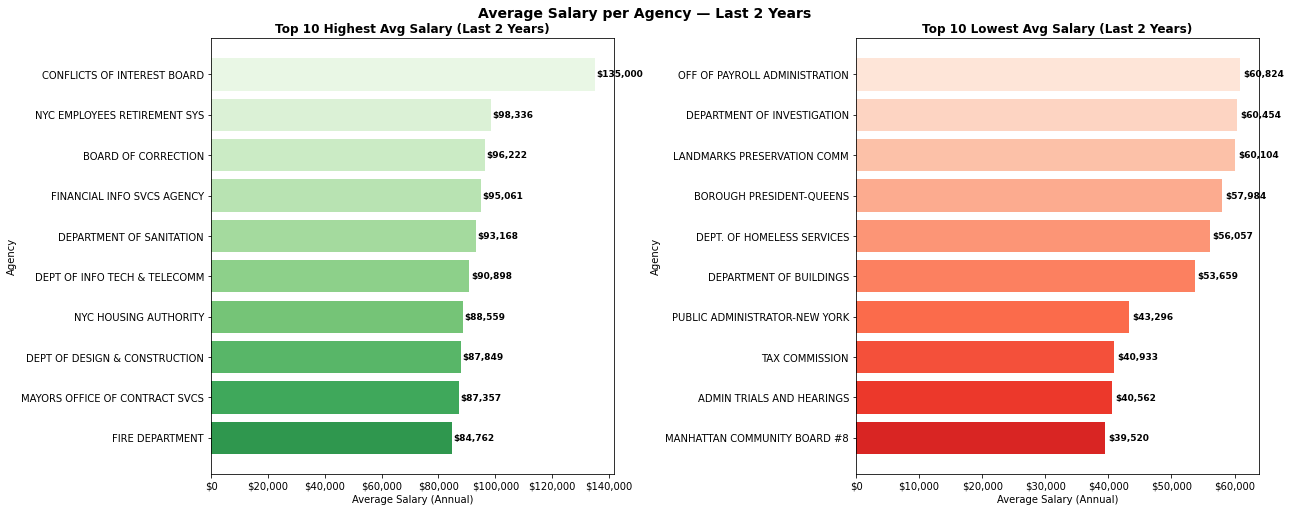

In [17]:
# 4.KPI4 – Average Salary Last 2 Years per Agency

# Side-by-side horizontal bar chart showing Top 10 Highest and Top 10 Lowest

kpi4_pd = kpi4.toPandas().sort_values(by="Avg_Salary_Last_2_Years", ascending=False)

# Split into Top 10 Highest and Top 10 Lowest
top10    = kpi4_pd.head(10)
bottom10 = kpi4_pd.tail(10).sort_values(by="Avg_Salary_Last_2_Years", ascending=False)

# Print row counts and display tables in descending order for both groups
print(f"Top 10 Highest Agencies")
display(top10)

print(f"Top 10 Lowest Agencies")
display(bottom10)

# Sort ascending for chart display (highest appears at top of horizontal bar)
top10_chart    = top10.sort_values(by="Avg_Salary_Last_2_Years", ascending=True)
bottom10_chart = bottom10.sort_values(by="Avg_Salary_Last_2_Years", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Top 10 Highest ──
bars_top = axes[0].barh(top10_chart["Agency"], top10_chart["Avg_Salary_Last_2_Years"],
                         color=cm.Greens_r(np.linspace(0.3, 0.9, len(top10_chart))))
for bar, value in zip(bars_top, top10_chart["Avg_Salary_Last_2_Years"]):
    axes[0].text(value + 500, bar.get_y() + bar.get_height() / 2,
                 f"${value:,.0f}", va='center', fontsize=9, fontweight='bold')
axes[0].set_title("Top 10 Highest Avg Salary (Last 2 Years)", fontweight='bold')
axes[0].set_xlabel("Average Salary (Annual)")
axes[0].set_ylabel("Agency")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── Right: Top 10 Lowest ──
bars_bot = axes[1].barh(bottom10_chart["Agency"], bottom10_chart["Avg_Salary_Last_2_Years"],
                         color=cm.Reds_r(np.linspace(0.3, 0.9, len(bottom10_chart))))
for bar, value in zip(bars_bot, bottom10_chart["Avg_Salary_Last_2_Years"]):
    axes[1].text(value + 500, bar.get_y() + bar.get_height() / 2,
                 f"${value:,.0f}", va='center', fontsize=9, fontweight='bold')
axes[1].set_title("Top 10 Lowest Avg Salary (Last 2 Years)", fontweight='bold')
axes[1].set_xlabel("Average Salary (Annual)")
axes[1].set_ylabel("Agency")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.suptitle("Average Salary per Agency — Last 2 Years", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5.KPI5 – Top 20 Highest Paid Skills

Row count: 278


,Skill,Avg_Salary
0,and supervisory techniques and principles,137253.200000
1,personnel management,137253.200000
2,public utility,133171.285714
3,MySQL,116821.416667
4,Exceptional leadership abilities,116680.900000


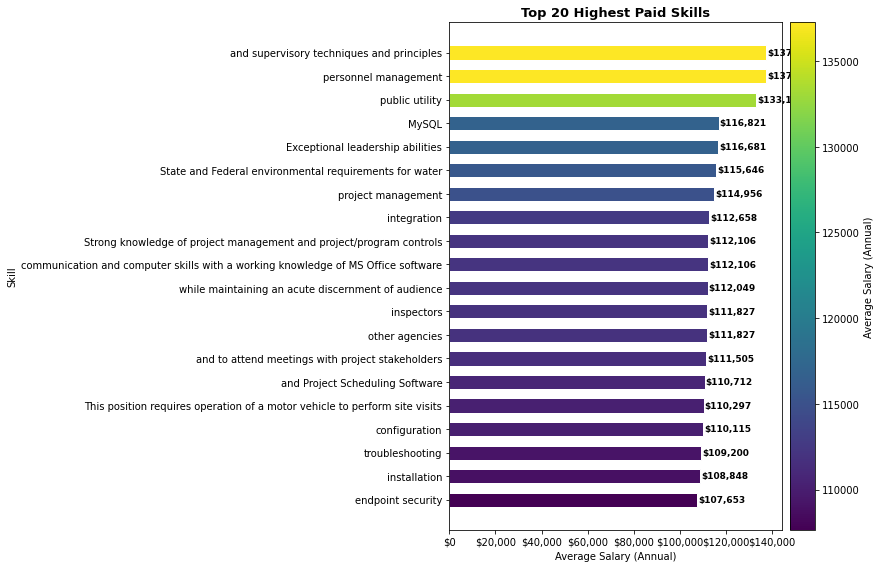

In [18]:
# 5.KPI5 – Top 20 Highest Paid Skills

print("Row count:", kpi5.count())
display(kpi5.limit(5).toPandas())

# Top 20 skills sorted ascending for chart (highest appears at top)
kpi5_pd = kpi5.limit(20).toPandas()
kpi5_pd = kpi5_pd.sort_values("Avg_Salary", ascending=True)

# Normalize salary for color gradient
norm   = plt.Normalize(kpi5_pd["Avg_Salary"].min(), kpi5_pd["Avg_Salary"].max())
colors = cm.viridis(norm(kpi5_pd["Avg_Salary"]))

plt.figure(figsize=(12, 8))
bars = plt.barh(kpi5_pd["Skill"], kpi5_pd["Avg_Salary"], color=colors, edgecolor='white', height=0.6)

# Add salary labels at end of each bar
for bar, value in zip(bars, kpi5_pd["Avg_Salary"]):
    plt.text(value + 500, bar.get_y() + bar.get_height() / 2,
             f"${value:,.0f}", va='center', fontsize=9, fontweight='bold')

# Add colorbar legend to show salary scale
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Average Salary (Annual)', pad=0.02)

plt.title("Top 20 Highest Paid Skills", fontweight='bold', fontsize=13)
plt.xlabel("Average Salary (Annual)")
plt.ylabel("Skill")

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

## 6.KPI6 – Degree vs Avg Salary

Row count: 6


,Degree_Level,Avg_Salary
0,Master,91458.940537
1,PhD,84036.897727
2,Unspecified,78261.650326
3,Bachelor,76732.131032
4,High school,62049.242960
5,Associate,55438.369231


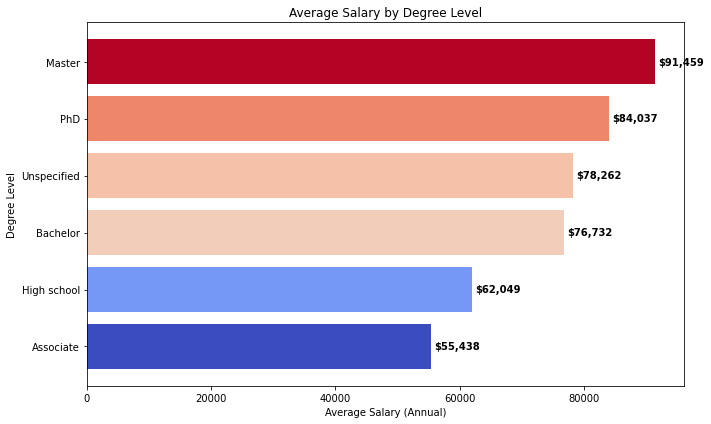

In [19]:
# 6.KPI6 – Degree vs Avg Salary

print("Row count:", kpi6.count())
display(kpi6.toPandas())

kpi6_pd = kpi6.toPandas()

# Sort by Avg_Salary ascending for horizontal bar (highest appears at top)
kpi6_pd = kpi6_pd.sort_values(by="Avg_Salary", ascending=True)

# Normalize colors by salary value
norm = plt.Normalize(kpi6_pd["Avg_Salary"].min(), kpi6_pd["Avg_Salary"].max())
colors = cm.coolwarm(norm(kpi6_pd["Avg_Salary"]))

plt.figure(figsize=(10, 6))
bars = plt.barh(kpi6_pd["Degree_Level"], kpi6_pd["Avg_Salary"], color=colors)

# Add salary labels at the end of each bar
for bar, value in zip(bars, kpi6_pd["Avg_Salary"]):
    plt.text(value + 500, bar.get_y() + bar.get_height() / 2,
             f"${value:,.0f}", va='center', fontweight='bold')

plt.title("Average Salary by Degree Level")
plt.xlabel("Average Salary (Annual)")
plt.ylabel("Degree Level")
plt.tight_layout()
plt.show()


# 5.Deployment Strategy

# Option 1 : Databricks + Control-M 

## Overview
This pipeline follows the Medallion Architecture (Bronze → Silver → Gold).
The recommended deployment approach is **Databricks** for execution and **Control-M** for scheduling and orchestration.

## Architecture
```
CSV (Raw Data) → Databricks Bronze Notebook → Databricks Silver Notebook → Databricks Gold Notebook (Parquet) → Visualizations
```

## Why Databricks + Control-M?
- Databricks provides **managed Spark clusters** — no infrastructure setup needed
- Notebooks can be run as **Databricks Jobs** directly
- Control-M provides **enterprise-grade scheduling** with dependency management
- Easy to **monitor, retry and alert** on failure via Control-M dashboard
- Databricks **Unity Catalog** manages parquet output with versioning
- Scales automatically based on data volume

## Deployment Steps

### Step 1 — Upload Notebooks to Databricks Workspace
```
Databricks Workspace/
  ├── /NYC_Jobs/
  │     ├── 01_bronze_layer.ipynb
  │     ├── 02_silver_layer.ipynb
  │     ├── 03_gold_layer.ipynb
  │     └── 04_visualizations.ipynb
```

### Step 2 — Upload Dataset to Databricks File System (DBFS)
```
DBFS:/
  └── FileStore/
        └── nyc_jobs/
              └── nyc-jobs.csv    ← Upload raw CSV here
```
Update path in Bronze Layer:
```python
csv_path = "dbfs:/FileStore/nyc_jobs/nyc-jobs.csv"
```

### Step 3 — Update Gold Layer Output Path for DBFS
```python
gold_path = "dbfs:/FileStore/nyc_jobs/gold/"
```
Each KPI will be saved as:
```
dbfs:/FileStore/nyc_jobs/gold/
  ├── top10_jobs/
  ├── salary_dist/
  ├── highest_salary_per_agency/
  ├── avg_salary_last_2_years/
  ├── highest_paid_skills/
  └── degree_salary_corr/
```

### Step 4 — Create Databricks Jobs for Each Layer
| Job Name              | Notebook                  | Cluster        | Trigger     |
|-----------------------|---------------------------|----------------|-------------|
| NYC_Bronze_Layer      | 01_bronze_layer.ipynb     | Job Cluster    | Control-M   |
| NYC_Silver_Layer      | 02_silver_layer.ipynb     | Job Cluster    | Control-M   |
| NYC_Gold_Layer        | 03_gold_layer.ipynb       | Job Cluster    | Control-M   |
| NYC_Visualizations    | 04_visualizations.ipynb   | Job Cluster    | Control-M   |

### Step 5 — Configure Databricks Cluster
```
Cluster Configuration:
  ├── Cluster Type    : Job Cluster (spins up on demand, cost efficient)
  ├── Runtime         : Databricks Runtime 13.x (Spark 3.4)
  ├── Node Type       : Standard_DS3_v2 (or equivalent)
  ├── Min Workers     : 1
  ├── Max Workers     : 4  (auto-scale based on data size)
  └── Libraries       : pyarrow, pandas, matplotlib, seaborn
```

### Step 6 — Control-M Job Configuration
```
Control-M Job Flow:
  ├── Job 1: NYC_Bronze_Layer
  │     ├── Type           : Databricks Job
  │     ├── Schedule       : Daily at 6:00 AM
  │     ├── On Success     : Trigger NYC_Silver_Layer
  │     └── On Failure     : Send Alert Email
  │
  ├── Job 2: NYC_Silver_Layer
  │     ├── Type           : Databricks Job
  │     ├── Depends On     : NYC_Bronze_Layer (Success)
  │     ├── On Success     : Trigger NYC_Gold_Layer
  │     └── On Failure     : Send Alert Email
  │
  ├── Job 3: NYC_Gold_Layer
  │     ├── Type           : Databricks Job
  │     ├── Depends On     : NYC_Silver_Layer (Success)
  │     ├── On Success     : Trigger NYC_Visualizations
  │     └── On Failure     : Send Alert Email
  │
  └── Job 4: NYC_Visualizations
        ├── Type           : Databricks Job
        ├── Depends On     : NYC_Gold_Layer (Success)
        ├── On Success     : Send Success Notification
        └── On Failure     : Send Alert Email
```

### Step 7 — Control-M Schedule Configuration
```
Schedule    : Daily at 6:00 AM
Time Zone   : EST
Retry       : 3 attempts with 5 min interval
Priority    : High
Calendar    : Business Days / All Days (as required)
```

### Step 8 — Version Parquet Output by Date
```python
from datetime import datetime
run_date  = datetime.now().strftime("%Y-%m-%d")
gold_path = f"dbfs:/FileStore/nyc_jobs/gold/{run_date}/"
```
Output structure:
```
dbfs:/FileStore/nyc_jobs/gold/
  ├── 2024-01-01/
  │     ├── top10_jobs/
  │     ├── salary_dist/
  │     └── ...
  └── 2024-01-02/
        ├── top10_jobs/
        └── ...
```

### Step 9 — Monitoring & Alerting
| Tool        | Purpose                              |
|-------------|--------------------------------------|
| Control-M   | Job status, dependency tracking      |
| Databricks  | Spark logs, cluster metrics          |
| Email Alert | Notify team on success/failure       |
| DBFS        | Validate parquet files after each run|

## Trigger Flow Summary
```
Control-M Scheduler (6:00 AM)
        │
        ▼
NYC_Bronze_Layer   (Databricks Job) ── Success ──▶ NYC_Silver_Layer
                                    ── Failure ──▶ Alert Email
        │
        ▼
NYC_Silver_Layer   (Databricks Job) ── Success ──▶ NYC_Gold_Layer
                                    ── Failure ──▶ Alert Email
        │
        ▼
NYC_Gold_Layer     (Databricks Job) ── Success ──▶ NYC_Visualizations
                                    ── Failure ──▶ Alert Email
        │
        ▼
NYC_Visualizations (Databricks Job) ── Success ──▶ Notify Team
                                    ── Failure ──▶ Alert Email
```

# Option 2: Apache Airflow + Docker

## Overview
This pipeline follows the Medallion Architecture (Bronze → Silver → Gold).
The recommended deployment approach is **Apache Airflow + Docker** for automated, scheduled execution.

## Architecture
```
CSV (Raw Data) → Bronze Layer → Silver Layer → Gold Layer (Parquet) → Visualizations
```

## Why Airflow?
- Pipeline has 3 clear layers (Bronze → Silver → Gold) which map perfectly to Airflow tasks
- Docker is already set up — adding Airflow is minimal effort
- Visual dashboard to monitor each layer's success/failure
- Easy to retry failed layers without rerunning the full pipeline
- Built-in logging and alerting out of the box

## Deployment Steps

### Step 1 — Convert Notebooks to Python Scripts
```
code/
  ├── bronze_layer.py
  ├── silver_layer.py
  ├── gold_layer.py
  └── pipeline.py        ← Single entry point
```

### Step 2 — Create Airflow DAG
```
dags/
  └── nyc_jobs_pipeline.py
      ├── bronze_task    (ingest CSV)
      ├── silver_task    (clean + feature engineering)
      └── gold_task      (KPI computation + parquet write)
```

### Step 3 — Schedule
- Pipeline runs **daily at 6 AM** automatically
- Schedule: `0 6 * * *`
- Each layer runs sequentially: `bronze >> silver >> gold`

### Step 4 — Updated docker-compose.yml
Add the following services to existing Docker setup:
- **Airflow**   → Scheduler + Web UI (port 8080)
- **Spark**     → Pipeline execution
- **Postgres**  → Airflow metadata storage

### Step 5 — Version Parquet Output
Each run saves output with date partition:
```
/notebook/nyc_gold/
  ├── 2024-01-01/
  │     ├── top10_jobs/
  │     ├── salary_dist/
  │     └── ...
  └── 2024-01-02/
        ├── top10_jobs/
        └── ...
```

### Step 6 — Monitor & Validate
- Airflow Web UI: http://localhost:8080
- Check row counts after each layer
- Email/Slack alert on pipeline failure

## Trigger Options
| Method          | Best For                        | Complexity |
|-----------------|---------------------------------|------------|
| Airflow DAG     | Complex scheduling + monitoring | Medium     |
| Cron Job        | Simple daily runs               | Low        |
| GitHub Actions  | Trigger on new data arrival     | Medium     |